In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../manifest_split.csv")
df["source_id"] = df["source_id"].fillna("").astype(str)

print("Total clips:", len(df))
print("Total hours:", round(df["duration_s"].sum() / 3600, 2))
df.groupby("district").agg(
    clips=("filepath", "count"),
    hours=("duration_s", lambda s: round(s.sum()/3600, 2)),
    avg_sec=("duration_s", "mean"),
).round(2)

Total clips: 9303
Total hours: 13.13


,clips,hours,avg_sec
district,,,
Barishal,1257,1.75,5.00
Chattogram,797,1.11,5.00
Dhaka,763,1.06,5.00
Formal,1652,2.51,5.47
Khulna,750,1.04,5.00
Mymensingh,1053,1.46,5.00
Noakhali,1213,1.68,5.00
Rajshahi,860,1.19,5.00
Sylhet,958,1.33,5.00


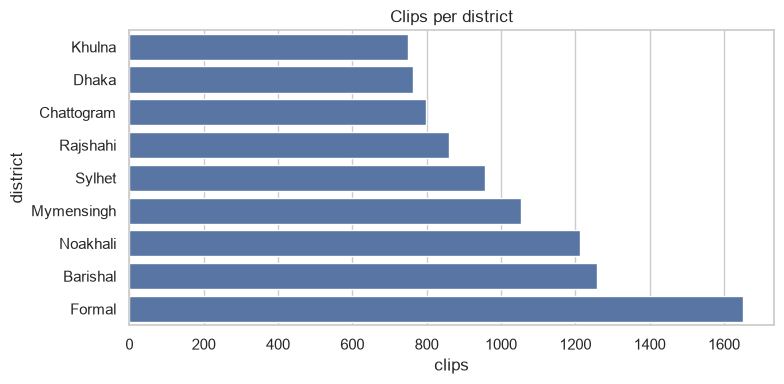

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

counts = df["district"].value_counts().sort_values()
plt.figure(figsize=(8, 4))
sns.barplot(x=counts.values, y=counts.index, orient="h")
plt.title("Clips per district")
plt.xlabel("clips")
plt.tight_layout()
plt.show()

In [3]:
pd.crosstab(df["district"], df["split"], margins=True)

split,test,train,val,All
district,,,,
Barishal,179,943,135,1257
Chattogram,114,598,85,797
Dhaka,109,573,81,763
Formal,236,1239,177,1652
Khulna,107,563,80,750
Mymensingh,151,789,113,1053
Noakhali,174,909,130,1213
Rajshahi,122,645,93,860
Sylhet,137,718,103,958


In [4]:
src = df[df["source_id"] != ""]
print("Clips with source_id:", len(src))
print("Distinct sources:", src["source_id"].nunique())
src.groupby("district")["source_id"].nunique().rename("distinct_sources")

Clips with source_id: 557
Distinct sources: 35


district
Formal    35
Name: distinct_sources, dtype: int64

In [5]:
d = np.load("../embeddings.npz", allow_pickle=True)
X, y, splits, labels = d["X"], d["y"], d["splits"], list(d["labels"])
print("Embeddings:", X.shape)          # (n_clips, 768)
print("Labels:", labels)
print({s: int((splits == s).sum()) for s in ["train", "val", "test"]})

Embeddings: (9303, 768)
Labels: [np.str_('Barishal'), np.str_('Chattogram'), np.str_('Dhaka'), np.str_('Formal'), np.str_('Khulna'), np.str_('Mymensingh'), np.str_('Noakhali'), np.str_('Rajshahi'), np.str_('Sylhet')]
{'train': 6977, 'val': 997, 'test': 1329}


In [6]:
import torch, torch.nn as nn
from sklearn.metrics import f1_score

torch.manual_seed(42)
np.random.seed(42)
device = "cpu"   # tiny MLP; CPU keeps the run deterministic across machines
tr = splits == "train"
mu, sd = X[tr].mean(0), X[tr].std(0) + 1e-6
Xn = (X - mu) / sd

def T(mask):
    return (torch.tensor(Xn[mask], dtype=torch.float32).to(device),
            torch.tensor(y[mask], dtype=torch.long).to(device))

Xtr, ytr = T(splits=="train"); Xva, yva = T(splits=="val"); Xte, yte = T(splits=="test")

counts = np.bincount(y[tr], minlength=len(labels))
w = torch.tensor(counts.sum()/(len(labels)*np.maximum(counts,1)), dtype=torch.float32).to(device)

model = nn.Sequential(
    nn.Linear(X.shape[1], 256), nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(256, 256), nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(256, len(labels)),
).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
lossf = nn.CrossEntropyLoss(weight=w)

hist, best_va, best_state = [], -1, None
for ep in range(60):
    model.train(); opt.zero_grad()
    loss = lossf(model(Xtr), ytr); loss.backward(); opt.step()
    model.eval()
    with torch.no_grad():
        va_f1 = f1_score(yva.cpu().numpy(), model(Xva).argmax(1).cpu().numpy(), average="macro")
    hist.append((ep, loss.item(), va_f1))
    if va_f1 > best_va:
        best_va, best_state = va_f1, {k: v.clone() for k, v in model.state_dict().items()}

model.load_state_dict(best_state)
print(f"best val macro-F1: {best_va:.4f}")

best val macro-F1: 0.9278


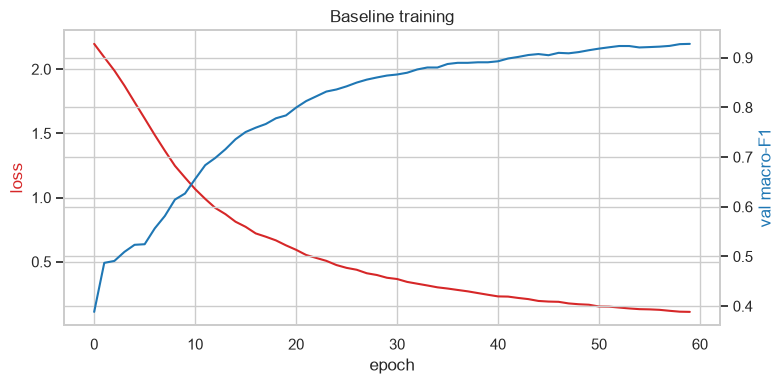

In [7]:
h = pd.DataFrame(hist, columns=["epoch", "loss", "val_macroF1"])
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(h["epoch"], h["loss"], color="tab:red", label="train loss")
ax1.set_xlabel("epoch"); ax1.set_ylabel("loss", color="tab:red")
ax2 = ax1.twinx()
ax2.plot(h["epoch"], h["val_macroF1"], color="tab:blue", label="val macro-F1")
ax2.set_ylabel("val macro-F1", color="tab:blue")
plt.title("Baseline training")
plt.tight_layout(); plt.show()

In [8]:
from sklearn.metrics import classification_report, f1_score

model.eval()
with torch.no_grad():
    te_pred = model(Xte).argmax(1).cpu().numpy()
yte_np = yte.cpu().numpy()

print("TEST macro-F1:", round(f1_score(yte_np, te_pred, average="macro"), 4))
print(classification_report(yte_np, te_pred, target_names=labels, digits=3))

TEST macro-F1: 0.9172
              precision    recall  f1-score   support

    Barishal      0.859     0.883     0.871       179
  Chattogram      0.892     0.868     0.880       114
       Dhaka      0.909     0.917     0.913       109
      Formal      0.978     0.962     0.970       236
      Khulna      0.973     1.000     0.986       107
  Mymensingh      0.928     0.854     0.890       151
    Noakhali      0.846     0.851     0.848       174
    Rajshahi      0.950     0.943     0.947       122
      Sylhet      0.918     0.985     0.951       137

    accuracy                          0.916      1329
   macro avg      0.917     0.918     0.917      1329
weighted avg      0.917     0.916     0.916      1329



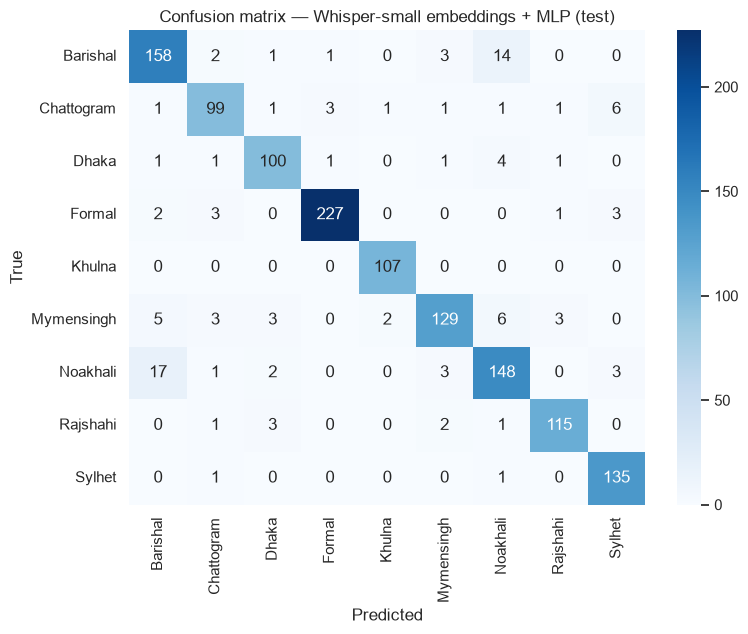

In [9]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(yte_np, te_pred)
plt.figure(figsize=(8, 6.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Confusion matrix — Whisper-small embeddings + MLP (test)")
plt.tight_layout()
plt.savefig("../reports/figures/confusion_matrix_baseline.png", dpi=200)
plt.show()

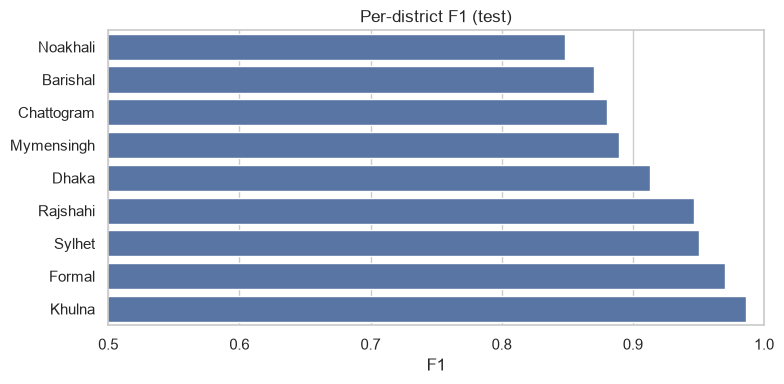

In [10]:
f1s = f1_score(yte_np, te_pred, average=None)
order = np.argsort(f1s)
plt.figure(figsize=(8, 4))
sns.barplot(x=f1s[order], y=np.array(labels)[order], orient="h")
plt.xlim(0.5, 1.0)
plt.title("Per-district F1 (test)")
plt.xlabel("F1")
plt.tight_layout()
plt.savefig("../reports/figures/per_class_f1_baseline.png", dpi=200)
plt.show()

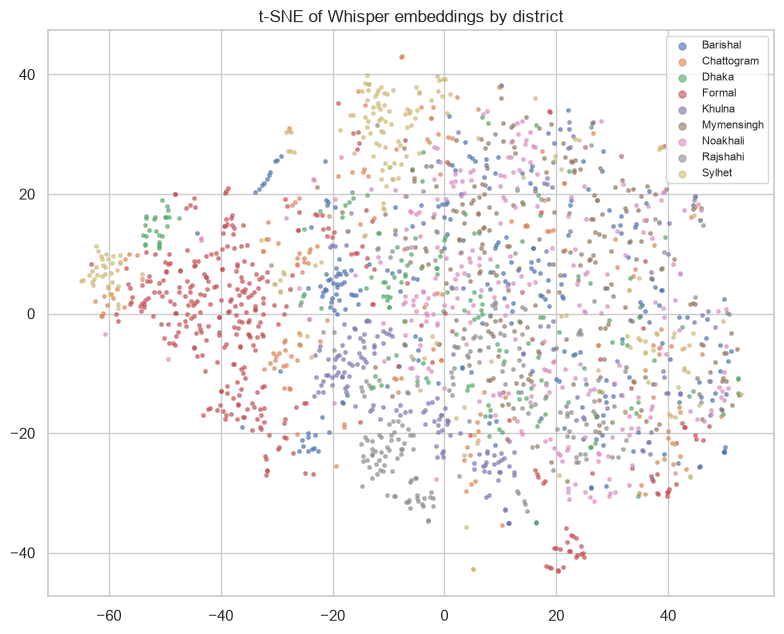

In [11]:
from sklearn.manifold import TSNE

sub = np.random.RandomState(42).choice(len(X), size=min(2000, len(X)), replace=False)
Z = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(Xn[sub])
plt.figure(figsize=(8, 6.5))
for i, lab in enumerate(labels):
    m = y[sub] == i
    plt.scatter(Z[m, 0], Z[m, 1], s=6, alpha=0.6, label=lab)
plt.legend(markerscale=2, fontsize=8)
plt.title("t-SNE of Whisper embeddings by district")
plt.tight_layout()
plt.savefig("../reports/figures/tsne_embeddings.png", dpi=200)
plt.show()